# Breast Cancer Classification (Scikit-Learn)

In this notebook, we build a simple ML pipeline to classify breast tumors as **malignant** or **benign** using the Breast Cancer Wisconsin (Diagnostic) dataset from scikit-learn.

We will:
- Load the dataset
- Explore basic properties
- Split into train and test sets
- Train a baseline Logistic Regression model
- Evaluate using accuracy, precision, recall, F1, and ROC-AUC
- Optionally compare with a Support Vector Machine (SVM) classifier

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

sns.set(style="whitegrid")

## 1. Load and inspect the dataset

We use `load_breast_cancer(as_frame=True)` to load the data as a pandas DataFrame.  
This dataset contains:
- 569 samples
- 30 numeric features describing cell nuclei (radius, texture, smoothness, etc.)
- A binary target: 0 = malignant, 1 = benign

In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data      # features DataFrame
y = data.target    # target Series

print("Feature shape:", X.shape)
print("Target shape :", y.shape)
print("Target classes:", data.target_names)

Feature shape: (569, 30)
Target shape : (569,)
Target classes: ['malignant' 'benign']


## 2. Quick EDA

We will:
- Look at the first few rows
- Check for missing values
- View basic descriptive statistics
- Inspect the class distribution

In [3]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
print("Missing values per column:\n")
print(X.isnull().sum())

Missing values per column:

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [5]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


Class counts:
 malignant    357
benign       212
Name: count, dtype: int64


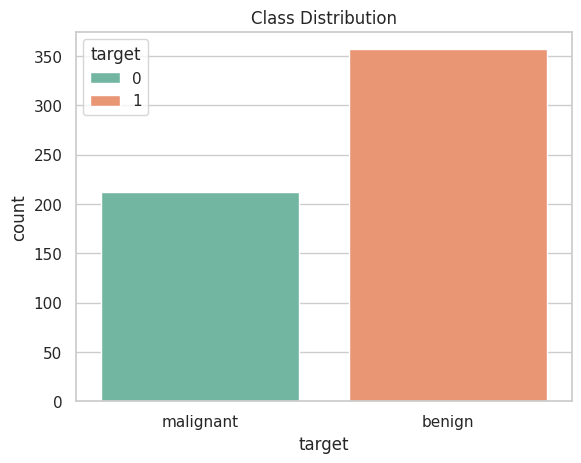

In [6]:
class_counts = y.value_counts()
class_counts.index = data.target_names  # map 0/1 to malignant/benign
print("Class counts:\n", class_counts)

sns.countplot(x=y, hue=y, palette="Set2")
plt.xticks([0, 1], data.target_names)
plt.title("Class Distribution")
plt.show()

## 3. Train-test split

We split the dataset into:
- 80% training data
- 20% test data

This helps us evaluate how well the model generalizes to unseen samples.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (455, 30)
X_test : (114, 30)


## 4. Baseline model: Logistic Regression

We start with a **Logistic Regression** classifier, which is a standard baseline for binary classification.

We will:
- Scale features with `StandardScaler`
- Fit `LogisticRegression`
- Evaluate performance on the test set

In [8]:
log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_lr = log_reg_pipeline.predict(X_test)
y_proba_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

## 5. Evaluation metrics (Logistic Regression)

We evaluate the model with:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

We also print a confusion matrix and a full classification report.

Logistic Regression performance:
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-score : 0.9861
ROC-AUC  : 0.9954

Classification report:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



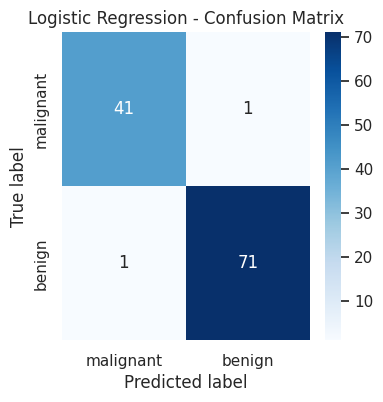

In [9]:
def evaluate_classification(y_true, y_pred, y_proba, model_name="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_proba)

    print(f"{model_name} performance:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")
    print("\nClassification report:\n")
    print(classification_report(y_true, y_pred, target_names=data.target_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=data.target_names,
                yticklabels=data.target_names)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

evaluate_classification(y_test, y_pred_lr, y_proba_lr, model_name="Logistic Regression")

## 6. Plot ROC curve (Logistic Regression)

The ROC curve shows the trade-off between **true positive rate** and **false positive rate** at different classification thresholds.

A higher area under the curve (AUC) indicates better separability between classes.

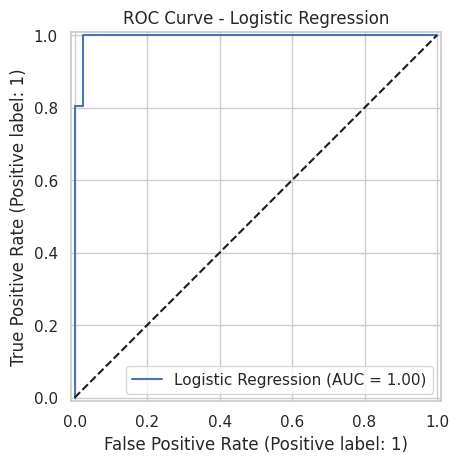

In [10]:
RocCurveDisplay.from_predictions(
    y_test,
    y_proba_lr,
    name="Logistic Regression"
)
plt.plot([0, 1], [0, 1], "k--")  # diagonal reference
plt.title("ROC Curve - Logistic Regression")
plt.show()

## 7. Second model: Support Vector Machine (SVM)

To compare with a stronger model, we train an SVM classifier with an RBF kernel.

We again:
- Scale features
- Train SVM
- Evaluate using the same metrics

SVM (RBF) performance:
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-score : 0.9861
ROC-AUC  : 0.9950

Classification report:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



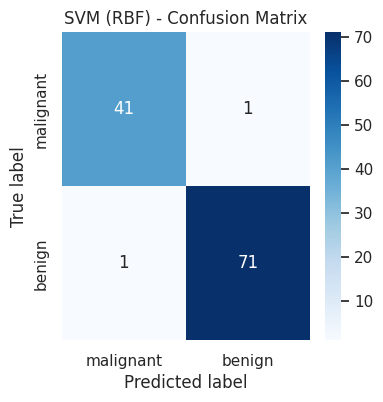

In [11]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", probability=True, random_state=42))
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)
y_proba_svm = svm_pipeline.predict_proba(X_test)[:, 1]

evaluate_classification(y_test, y_pred_svm, y_proba_svm, model_name="SVM (RBF)")

## 8. Compare models

We create a small table to compare Logistic Regression and SVM.

You can use this to decide whether the extra complexity of SVM is worth it for this dataset.

In [12]:
def get_scores(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_proba),
    }

scores_lr = get_scores(y_test, y_pred_lr, y_proba_lr)
scores_svm = get_scores(y_test, y_pred_svm, y_proba_svm)

results = pd.DataFrame([scores_lr, scores_svm],
                       index=["Logistic Regression", "SVM (RBF)"])
results

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.99537
SVM (RBF),0.982456,0.986111,0.986111,0.986111,0.99504


## 9. Feature importance / coefficients (Logistic Regression)

For Logistic Regression, we can inspect the learned coefficients to see which features contribute positively or negatively to predicting a benign tumor.

We will:
- Extract coefficients from the trained model
- Map them to feature names
- Sort and visualize them

In [13]:
# Access the underlying LogisticRegression model inside the pipeline
lr_model = log_reg_pipeline.named_steps["model"]

coef = lr_model.coef_[0]
feature_importance = pd.Series(coef, index=X.columns).sort_values()

feature_importance

,0
worst texture,-1.255088
radius error,-1.082965
worst concave points,-0.953686
worst area,-0.947756
worst radius,-0.947616
worst symmetry,-0.939181
area error,-0.929104
worst concavity,-0.823151
worst perimeter,-0.763220
worst smoothness,-0.746625


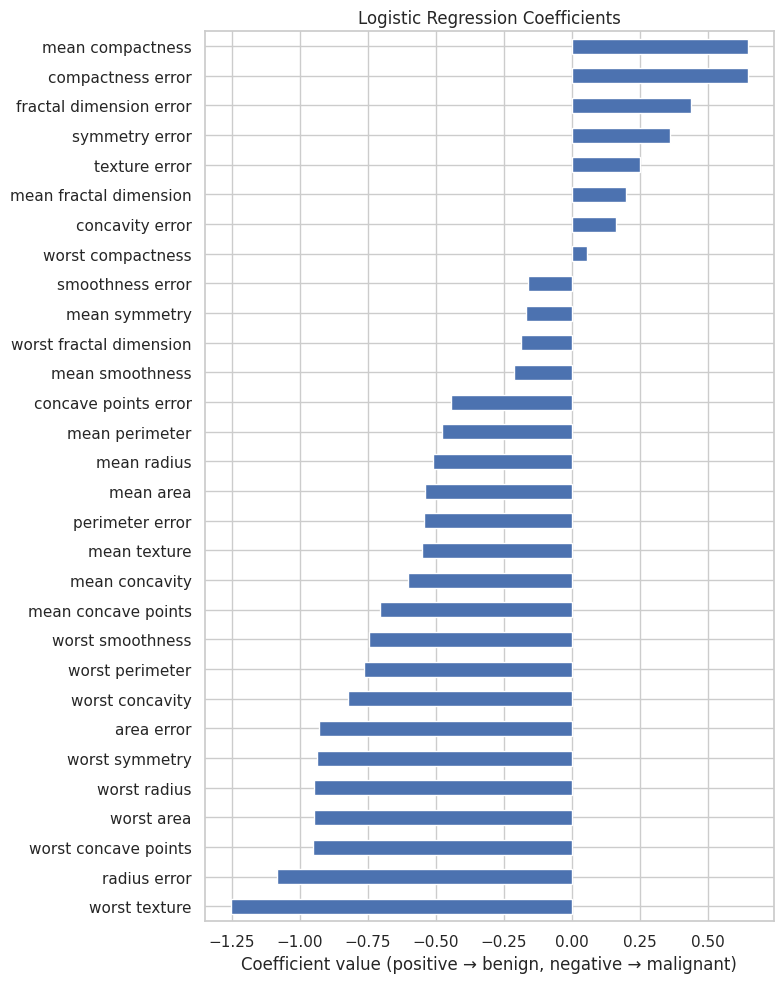

In [14]:
plt.figure(figsize=(8, 10))
feature_importance.plot(kind="barh")
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient value (positive → benign, negative → malignant)")
plt.tight_layout()
plt.show()

## 10. Summary

In this notebook we:

- Loaded the Breast Cancer Wisconsin (Diagnostic) dataset
- Explored its shape, class balance, and feature statistics
- Split the data into training and test sets with stratification
- Trained and evaluated:
  - Logistic Regression (baseline)
  - SVM with RBF kernel (stronger non-linear model)
- Compared metrics (accuracy, precision, recall, F1, ROC-AUC)
- Visualized confusion matrices, ROC curves, and Logistic Regression coefficients

This completes a full binary classification workflow on a classic, medically relevant dataset.